## Carga de datos y vista rápida

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv('/datasets/oecd_city_economy.csv')

In [4]:
traffic.head(5)

,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [5]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


##  Exploraración, limpieza y preparación de los datos

In [6]:
# Examinar la estructura de traffic
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

In [7]:
# Examinar la estructura de eco
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


### Renombramiento de columnas

In [8]:
# Estandarizar los nombres de las columnas de traffic
traffic.columns=['country', 'city', 'update_time_utc', 'jams_delay', 'traffic_index_live', 'jams_length_kms', 
                'jams_count', 'traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per10_kms_mins', 
                 'travel_time_historic_per10_kms_mins','mins_delay']

# verificar cambios
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per10_kms_mins',
       'travel_time_historic_per10_kms_mins', 'mins_delay'],
      dtype='object')

In [9]:
# Estandarizar los nombres de las columnas de eco
eco.columns=['year', 'city', 'country_full', 'city_gdp_capita', 'unemployment_pct', 'pm25', 'population_m']

# verificar cambios
eco.columns

Index(['year', 'city', 'country_full', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m'],
      dtype='object')

### Corrección de formatos numéricos y de fecha

In [10]:
# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], utc=True, errors='ignore')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], utc=True, errors='ignore')

# verificar el cambio
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                               Non-Null Count    Dtype              
---  ------                               --------------    -----              
 0   country                              1004464 non-null  object             
 1   city                                 1004464 non-null  object             
 2   update_time_utc                      1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                           1004464 non-null  float64            
 4   traffic_index_live                   1004464 non-null  float64            
 5   jams_length_kms                      1004464 non-null  float64            
 6   jams_count                           1004464 non-null  float64            
 7   traffic_index_week_ago               1004464 non-null  float64            
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns, UTC]
 9   tr

In [11]:
# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco['city_gdp_capita'].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco['unemployment_pct'].astype(str).str.replace('%', '').str.replace(',', '.').astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country_full      30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country_full,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0


## Extraer año y filtrar

### Extraer columna año y filtrar 2024

In [12]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = pd.to_datetime(traffic['update_time_utc']).dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [13]:
# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year']== 2024].copy()

#mapeo de paises ISO a full name para hacer coincidir en el merge 
iso_to_country = {
    'ARE': 'United Arab Emirates',
    'ARG': 'Argentina',
    'AUS': 'Australia',
    'AUT': 'Austria',
    'BEL': 'Belgium',
    'BGR': 'Bulgaria',
    'BRA': 'Brazil',
    'CAN': 'Canada',
    'CHE': 'Switzerland',
    'CHL': 'Chile',
    'COL': 'Colombia',
    'CZE': 'Czech Republic',
    'DEU': 'Germany',
    'DNK': 'Denmark',
    'EGY': 'Egypt',
    'ESP': 'Spain',
    'EST': 'Estonia',
    'FIN': 'Finland',
    'FRA': 'France',
    'GBR': 'United Kingdom',
    'GRC': 'Greece',
    'HKG': 'Hong Kong',
    'HUN': 'Hungary',
    'IDN': 'Indonesia',
    'IND': 'India',
    'IRL': 'Ireland',
    'ISL': 'Iceland',
    'ITA': 'Italy',
    'JPN': 'Japan',
    'KWT': 'Kuwait',
    'LTU': 'Lithuania',
    'LUX': 'Luxembourg',
    'LVA': 'Latvia',
    'MEX': 'Mexico',
    'MYS': 'Malaysia',
    'NLD': 'Netherlands',
    'NOR': 'Norway',
    'NZL': 'New Zealand',
    'PER': 'Peru',
    'PHL': 'Philippines',
    'POL': 'Poland',
    'PRT': 'Portugal',
    'QAT': 'Qatar',
    'ROU': 'Romania',
    'SAU': 'Saudi Arabia',
    'SGP': 'Singapore',
    'SVK': 'Slovakia',
    'SVN': 'Slovenia',
    'SWE': 'Sweden',
    'THA': 'Thailand',
    'TUR': 'Turkey',
    'TWN': 'Taiwan',
    'URY': 'Uruguay',
    'USA': 'United States',
    'ZAF': 'South Africa' 
}

# Agrega columna country_full al dataset filtrado
traffic_2024['country_full'] = traffic_2024['country'].map(iso_to_country)


eco_2024 = eco[eco['year']== 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head(20))


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,mins_delay,year,country_full
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024,United Arab Emirates
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024,United Arab Emirates
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024,United Arab Emirates
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024,United Arab Emirates
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024,United Arab Emirates


,year,city,country_full,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0
20,2024,fortaleza,Brazil,8512.0,11.8,"14,60",4.2,4200000.0
21,2024,belo-horizonte,Brazil,11124.0,9.5,"16,80",6.1,6100000.0
22,2024,curitiba,Brazil,12381.0,8.2,"13,50",3.7,3700000.0
23,2024,recife,Brazil,9189.0,11.2,"15,80",4.1,4100000.0
24,2024,porto-alegre,Brazil,11801.0,8.7,"14,20",4.3,4300000.0


##  Analizar y resumir datos de movilidad

### Calculo de promedios de tráfico por ciudad

In [14]:
# Calcular los  promedios de trafico por ciudad, país y año
traffic_city_year_2024 =  traffic_2024.groupby(['city', 'country_full', 'year'])[['jams_delay', 'traffic_index_live', 'jams_length_kms', 
                'jams_count', 'mins_delay','traffic_index_week_ago', 'update_time_utc_week_ago', 'travel_time_live_per10_kms_mins', 
                 'travel_time_historic_per10_kms_mins']].mean().reset_index()

# Mostrar resultado
traffic_city_year_2024.head()

,city,country_full,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,traffic_index_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins
0,a-coruna,Spain,2024,17.935187,15.259774,2.198002,4.934405,0.774172,15.821025,16.267977,15.493804
1,aachen,Germany,2024,26.732141,20.960314,3.892586,6.601832,0.792968,21.874836,13.397861,12.604894
2,aarhus,Denmark,2024,21.200616,16.575891,2.736736,6.109987,0.495276,17.445227,15.219292,14.724016
3,abu-dhabi,United Arab Emirates,2024,171.157315,13.902028,24.507380,47.268019,0.139764,14.295209,9.829092,9.689328
4,adana,Turkey,2024,83.864761,22.541040,11.827331,23.754620,1.129749,22.508810,15.879694,14.749945


In [15]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False).reset_index(drop=True)

,city,country_full,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,traffic_index_week_ago,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins
0,mexico-city,Mexico,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,36.443813,21.809092,19.953550
1,tokyo,Japan,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,37.441779,22.443778,21.745626
2,new-york,United States,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,29.337407,18.505043,17.108691
3,london,United Kingdom,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,30.827376,17.714139,16.388979
4,manila,Philippines,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,68.628341,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...,...
382,dunedin,New Zealand,2024,4.651175,15.430809,0.712315,1.591384,0.633294,15.975631,16.226009,15.592715
383,uppsala,Sweden,2024,4.194486,13.939168,0.656368,1.349672,0.501802,14.470460,15.746717,15.244916
384,fujairah,United Arab Emirates,2024,4.025959,10.907719,0.731910,1.373006,0.194951,10.938767,11.662590,11.467639
385,almere,Netherlands,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,6.666082,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es Ciudad de México, México

## Union de Data Frames

In [16]:
# Seleccionar columnas clave de tráfico y economía.....traffic
left_cols = ['city','country_full','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per10_kms_mins','travel_time_historic_per10_kms_mins']

# data frame eco 
right_cols = ['country_full', 'city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on=[ 'city', 'year'], how='inner').sort_values('jams_delay', ascending=False).reset_index(drop =True)

# Mostrar las primeras 5 filas
merged.head(10)

,city,country_full_x,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per10_kms_mins,travel_time_historic_per10_kms_mins,country_full_y,city_gdp_capita,unemployment_pct,pm25,population
0,mexico-city,Mexico,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550,Mexico,21111.0,3.2,"22,30",22100000.0
1,sao-paulo,Brazil,2024,1729.189270,26.877932,238.419896,431.470460,1.129026,20.801836,19.672810,Brazil,14703.0,8.5,"28,00",22600000.0
2,bogota,Colombia,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,Colombia,11442.0,10.0,"17,60",11300000.0
3,lima,Peru,2024,1052.292789,31.031277,110.314770,213.453519,1.506305,25.674261,24.167956,Peru,13472.0,6.5,"19,70",11200000.0
4,santiago,Chile,2024,629.865318,20.155352,93.489121,153.095300,0.627445,17.031310,16.403864,Chile,2277.0,7.8,"21,30",7100000.0
5,buenos-aires,Argentina,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,Argentina,18117.0,7.2,"14,50",15400000.0
6,rio-de-janeiro,Brazil,2024,466.064706,25.162963,85.015120,123.891939,0.361302,17.137320,16.776018,Brazil,13349.0,9.2,"18,40",13700000.0
7,belo-horizonte,Brazil,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,Brazil,11124.0,9.5,"16,80",6100000.0
8,curitiba,Brazil,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,Brazil,12381.0,8.2,"13,50",3700000.0
9,porto-alegre,Brazil,2024,139.382830,17.687254,20.167849,39.813403,0.194195,16.166684,15.972490,Brazil,11801.0,8.7,"14,20",4300000.0


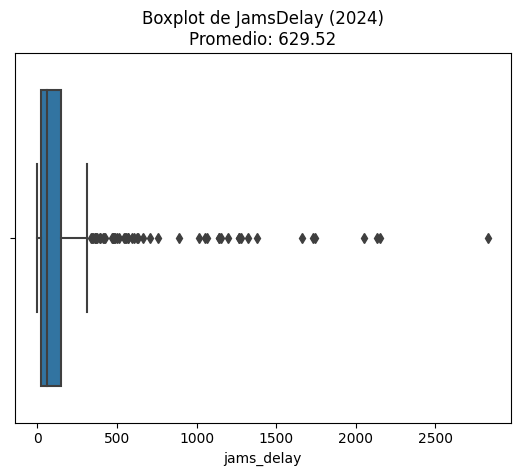

In [17]:
# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
sns.boxplot(data = traffic_2024_small, x= 'jams_delay')
plt.show()


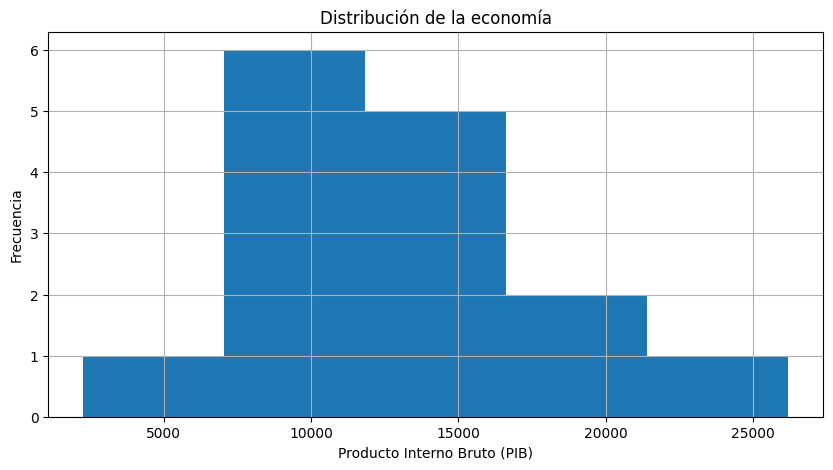

In [18]:
# Crear histograma para ver la distribución de la economía (city_gdp_capita)
eco_2024_small['city_gdp_capita'].hist(bins=5, figsize= (10,5))
plt.title('Distribución de la economía')
plt.xlabel('Producto Interno Bruto (PIB)')
plt.ylabel('Frecuencia')
plt.show()


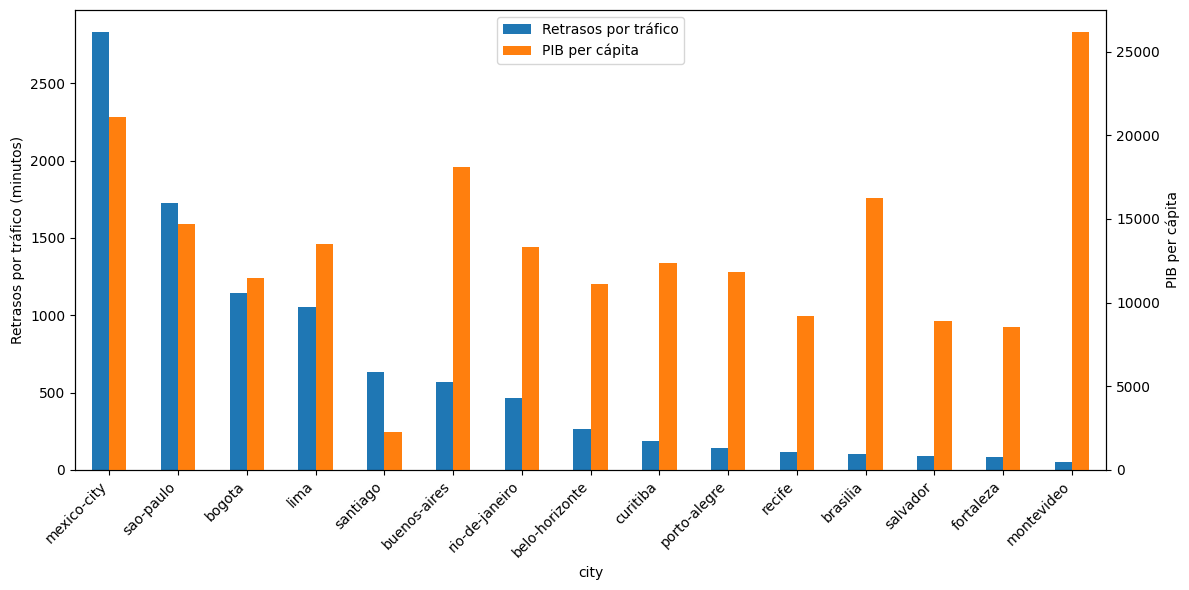

In [19]:
# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad
# ajuste de alineación
ax = merged.plot(x='city', y=['jams_delay', 'city_gdp_capita'], kind='bar', figsize=(12,6), secondary_y=['city_gdp_capita'])

#Juntamos las etiquetas de ambos ejes
lines_1, labels_1 = ax.get_legend_handles_labels()
lines_2, labels_2 = ax.right_ax.get_legend_handles_labels()
ax.legend(lines_1 + lines_2, ["Retrasos por tráfico", "PIB per cápita"], loc='upper center')

# Nombres de los ejes 
ax.set_ylabel('Retrasos por tráfico (minutos)')
ax.right_ax.set_ylabel('PIB per cápita')

ax.set_xticklabels(merged['city'], rotation=45, ha='right')

# Alineamiento horizontal 
plt.xticks(rotation=45, ha='right') 

plt.tight_layout() # Para que no se corte el texto abajo
plt.show()

In [20]:
# Exportación el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)


---

# 🧾 Resumen ejecutivo



**Contexto & objetivo:**  
El presente análisis surge de la necesidad de entender la relación entre el desarrollo económico y la eficiencia operativa en las principales metrópolis de América Latina. El objetivo central es determinar si existe una correlación directa entre el PIB per cápita y los niveles de congestión vehicular durante 2024. Se busca identificar si el crecimiento económico está generando cuellos de botella que comprometan la productividad urbana o si, por el contrario, existen ciudades que han logrado desacoplar su riqueza del caos vial.
  
**Cobertura de datos:**  
- En este análisis se incluyeron ciudades (15) de diferentes paises de Ámerica Latina (México, Brasil, Colombia, Perú, Chile, Argentina y Uruguay) presentes en los data frames de movilidad y economía.

**Metodología (alto nivel):**  
-Exploración e Inspección de Datos: Se realizó un análisis inicial de las estructuras de los datasets originales (movilidad y economía) para identificar tipos de variables, dimensiones y posibles inconsistencias.

-Procesamiento y Limpieza: Se ejecutaron tareas de limpieza de datos, que incluyeron el manejo de valores nulos y el formateo de columnas críticas (especialmente fechas y variables numéricas) para asegurar la compatibilidad entre ambos conjuntos de datos.

-Análisis Estadístico Descriptivo: Se calcularon medidas de tendencia central y dispersión, agrupando la información por ciudad, país y año (enfocándose en el periodo 2024). Este paso permitió consolidar las variables de interés, como el promedio de retrasos por tráfico y el PIB per cápita.

-Integración de Datos (Data Merging): Se llevó a cabo una unión de tipo inner join utilizando como llaves de enlace las columnas de ciudad y año. Esto resultó en un dataset consolidado que integra métricas de movilidad y economía, permitiendo un análisis multivariado de la relación entre el desarrollo económico y el tráfico urbano.

**Hallazgos iniciales:**  
- Se evaluaron variables como el retraso provocado por el tráfico en diferentes ciudades de America Latina. La distribución de esta variable muestra una marcada asimetría y falta de normalidad, caracterizada por una alta variabilidad y una presencia significativa de valores atípicos que se extienden hasta superar las 2500 unidades. Esta dispersión provoca que el promedio (629.52) se vea fuertemente influenciado por eventos extremos, lo que indica que los retrasos son altamente impredecibles y que la mayoría de los incidentes se concentran en rangos menores a los que sugiere la media aritmética.
  
- Por otro lado, la distribución de la economia (PIB) en los paises de LATAM confirma una desviación de la distribución normal, presentando una asimetría positiva (sesgada a la derecha). La mayor concentración de registros se localiza en el rango de 7,500 a 12,500 unidades de PIB, mientras que la frecuencia disminuye notablemente hacia los valores superiores. Esta estructura indica que la economía analizada está compuesta mayoritariamente por registros de ingresos medios-bajos, con una "cola" de datos que representa a un número reducido de casos con un PIB significativamente más alto, lo cual valida la necesidad de aplicar pruebas no paramétricas para cualquier análisis estadístico posterior.

- Al contrastar los Retrasos por tráfico con el PIB per cápita, se observa una falta de correlación lineal directa, lo que sugiere que el nivel económico de una ciudad no es el único determinante de su congestión. Es fundamental destacar que este análisis requiere una normalización por población total, ya que el volumen de habitantes actúa como una variable de confusión crítica: ciudades con PIB alto pero densidades poblacionales menores pueden presentar retrasos bajos, mientras que grandes metrópolis (como Mexico City o Sao Paulo) muestran niveles críticos de tráfico que podrían estar más vinculados al parque vehicular y la infraestructura que a la riqueza per cápita individual.

**Recomendaciones**  
- Se recomienda contrastar los resultados actuales con métricas de ciudades de la Unión Europea. Esto permitiría determinar si la relación entre el PIB y el caos vial es una constante global o si responde a deficiencias estructurales específicas de la región latinoamericana.

- Para robustecer el análisis, es necesario incorporar indicadores de infraestructura vial, niveles de inversión pública en transporte y calidad de vida. Esto ayudará a discernir si el tráfico es consecuencia directa de la riqueza o si puede mitigarse mediante una gestión urbana eficiente.

- Identificar y estudiar "ciudades modelo" dentro de la muestra que presenten un PIB alto con bajos niveles de congestión, con el fin de replicar sus estrategias de movilidad en otros centros urbanos.

- Para refinar la precisión del modelo, se propone la integración de la densidad poblacional y la extensión territorial como variables de control. Un análisis preliminar sugiere que el PIB per cápita no es un predictor aislado; la eficiencia en la movilidad parece estar condicionada por la morfología urbana. Al incluir la densidad, podremos identificar si los retrasos son producto de la concentración de actividades en centros urbanos saturados o si obedecen a un modelo de expansión territorial que obliga a realizar trayectos más largos, permitiendo así establecer objetivos de planeación a largo plazo más realistas y segmentados por tipología de ciudad.
